#AdventureWorks Analys

I denna analys undersöker vi AdventureWorks-databasen för att besvara affärsfrågor som exempelvis:
- Produktkategorier och deras försäljning
- Försäljningstränder över tid
- Regional försäljning

Vi använder sql för att hämta data och python för visualisering och analys.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus


user = "SA"
password = quote_plus("BytMig123!")
server = "localhost:1433"
database = "AdventureWorks"
driver = quote_plus("ODBC Driver 18 for SQL server")


connection_string = (
    f"mssql+pyodbc://{user}:{password}@{server}/{database}"
    f"?driver={driver}&Encrypt=yes&TrustServerCertificate=yes"
)

engine = create_engine(connection_string)

try:
    with engine.connect():
        print("Success")
except Exception as e:
    print("Error", e)        


Success


C:\Users\dropz\AppData\Local\Temp\ipykernel_23732\2734569936.py:22: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  with engine.connect():


In [2]:
def query_df(sql: str):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

## Visualisering 1: Antal produkter per kategori
hur många produkter finns i varje kategori?

Tabeller som används:
Production.ProductCategory
Production.ProductSubcategory
Production.Product

Plan:
Joina tabellerna
Räkna DISTINCT produkter per kategori
Skapa vertikalt stapeldiagram
Analysera resultatet



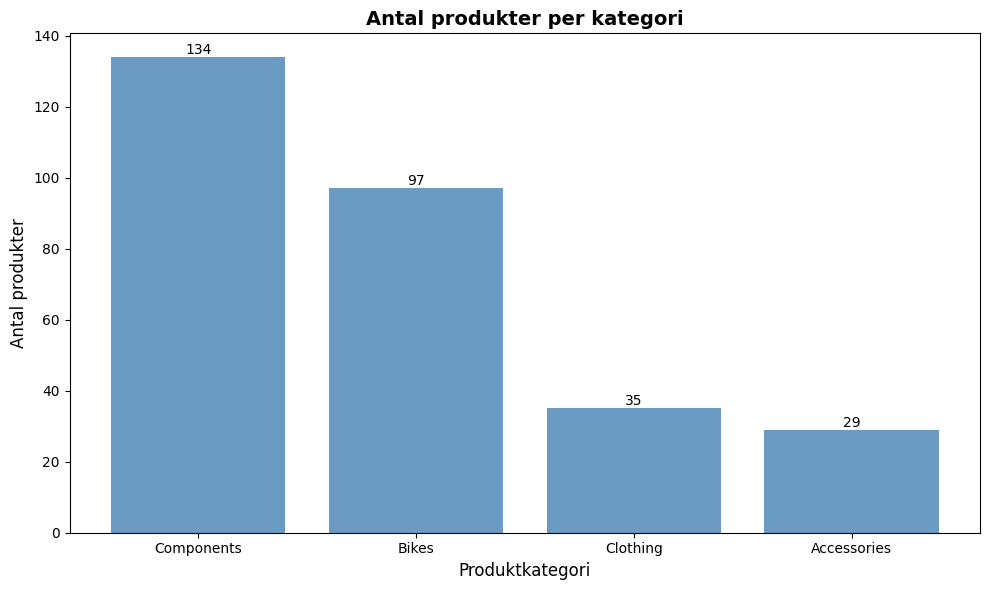

In [3]:
query_vis1 = """
SELECT
    pc.Name AS CategoryName,
    COUNT(DISTINCT p.ProductID) AS ProductCount
    
FROM production.ProductCategory pc
INNER JOIN Production.ProductSubcategory psc ON pc.ProductCategoryID = psc.ProductCategoryID
INNER JOIN Production.Product p ON psc.ProductSubcategoryID = p.ProductSubcategoryID
GROUP BY pc.Name
ORDER BY ProductCount DESC
"""

df_vis1 = query_df(query_vis1)


fig, ax = plt.subplots(figsize=(10,6))


bars = ax.bar (df_vis1['CategoryName'],df_vis1['ProductCount'], color='steelblue', alpha=0.8)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'    
    )
  

ax.set_xlabel('Produktkategori', fontsize=12)
ax.set_ylabel('Antal produkter', fontsize=12)
ax.set_title('Antal produkter per kategori', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



### Insikter - Antal produkter perkategori
Components är största kategorin med 134 produkter.
Accessories är minst med 29 produkter.
Detta indikerar att företaget är starkt fokuserat på komponenter och reservdelar.
Och att accessories kan vara ett utvecklingsområde.

## Visualisering 2 = Försäljning per produktkategori.
Vilka produktkategorier genererar mest intäkter?

Tabeller som används:

Production.ProductCategory 
Production.ProductSubcategory
Production.Product
Sales.SalesOrderDetail

Plan:
Joina tabellerna
Sortera från högst till lägst försäljning
Skapa horisontellt stapeldiagram
Analysera resultatet



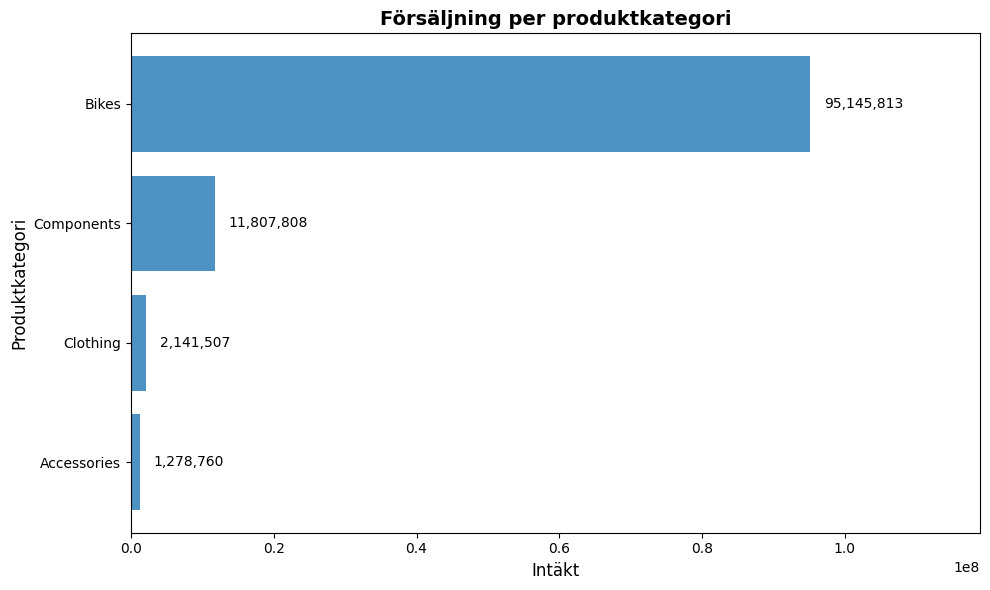

In [12]:
query_vis2 = """
SELECT
    pc.Name AS CategoryName,
    SUM(sod.OrderQty * sod.UnitPrice) AS TotalRevenue
    
FROM Production.ProductCategory pc
INNER JOIN Production.ProductSubcategory psc ON pc.ProductCategoryID = psc.ProductCategoryID
INNER JOIN Production.Product p ON psc.ProductSubcategoryID = p.ProductSubcategoryID
INNER JOIN Sales.SalesOrderDetail sod ON sod.ProductID = p.ProductID
GROUP BY pc.Name
ORDER BY TotalRevenue DESC
"""

df_vis2 = query_df(query_vis2)


df_vis2["TotalRevenue"] = pd.to_numeric(df_vis2["TotalRevenue"])

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(df_vis2["CategoryName"], df_vis2["TotalRevenue"], alpha=0.8)


ax.invert_yaxis()

max_val = df_vis2["TotalRevenue"].max()


ax.set_xlim(0, max_val * 1.25)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max_val * 0.02,                
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",                      
        va="center",
        ha="left"
    )

ax.set_xlabel("Intäkt", fontsize=12)
ax.set_ylabel("Produktkategori", fontsize=12)
ax.set_title("Försäljning per produktkategori", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()



### Insikter  -  Försäljning per produktkategori

Bikes är den kategori som genererar mest intekter och acessories ger minst intäkter.

Detta indikerar att cyklar står för den största delen av företagets omsättning.
accessories genererar ganska lite pengar och behöver pushas lite för att öka försäljningen.